In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
df = pd.read_csv("PJME_preprocessed.csv",index_col="Datetime",parse_dates=True)
df.head()

,PJME_MW,Hour,Day,DayOfWeek,Month,Year,Week,IsWeekend,Season,Hour_sin,...,Month_sin,Month_cos,Lag_1,Lag_24,Lag_48,Lag_168,RollingMean_24,RollingMean_168,RollingStd_24,RollingStd_168
Datetime,,,,,,,,,,,,,,,,,,,,,
2002-01-08 01:00:00,29445.0,1,8,1,1,2002,2,0,Winter,0.258819,...,0.5,0.866025,31187.0,26862.0,27100.0,30393.0,33560.208333,32513.869048,4425.965952,3861.770954
2002-01-08 02:00:00,28670.0,2,8,1,1,2002,2,0,Winter,0.500000,...,0.5,0.866025,29445.0,25976.0,26097.0,29265.0,33672.458333,32510.327381,4256.159403,3865.039821
2002-01-08 03:00:00,28375.0,3,8,1,1,2002,2,0,Winter,0.707107,...,0.5,0.866025,28670.0,25641.0,25793.0,28357.0,33786.375000,32510.434524,4064.104959,3864.924245
2002-01-08 04:00:00,28542.0,4,8,1,1,2002,2,0,Winter,0.866025,...,0.5,0.866025,28375.0,25666.0,25657.0,27899.0,33906.208333,32514.261905,3851.076461,3860.646270
2002-01-08 05:00:00,29261.0,5,8,1,1,2002,2,0,Winter,0.965926,...,0.5,0.866025,28542.0,26328.0,25778.0,28057.0,34028.416667,32521.428571,3640.941409,3853.433314


In [3]:
df.shape

(145224, 23)

In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 145224 entries, 2002-01-08 01:00:00 to 2018-08-03 00:00:00
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   PJME_MW          145224 non-null  float64
 1   Hour             145224 non-null  int64  
 2   Day              145224 non-null  int64  
 3   DayOfWeek        145224 non-null  int64  
 4   Month            145224 non-null  int64  
 5   Year             145224 non-null  int64  
 6   Week             145224 non-null  int64  
 7   IsWeekend        145224 non-null  int64  
 8   Season           145224 non-null  str    
 9   Hour_sin         145224 non-null  float64
 10  Hour_cos         145224 non-null  float64
 11  DayOfWeek_sin    145224 non-null  float64
 12  DayOfWeek_cos    145224 non-null  float64
 13  Month_sin        145224 non-null  float64
 14  Month_cos        145224 non-null  float64
 15  Lag_1            145224 non-null  float64
 16  Lag_24         

In [5]:
df.isnull().sum()

PJME_MW            0
Hour               0
Day                0
DayOfWeek          0
Month              0
Year               0
Week               0
IsWeekend          0
Season             0
Hour_sin           0
Hour_cos           0
DayOfWeek_sin      0
DayOfWeek_cos      0
Month_sin          0
Month_cos          0
Lag_1              0
Lag_24             0
Lag_48             0
Lag_168            0
RollingMean_24     0
RollingMean_168    0
RollingStd_24      0
RollingStd_168     0
dtype: int64

In [7]:
print(df.index.min())
print(df.index.max())

2002-01-08 01:00:00
2018-08-03 00:00:00


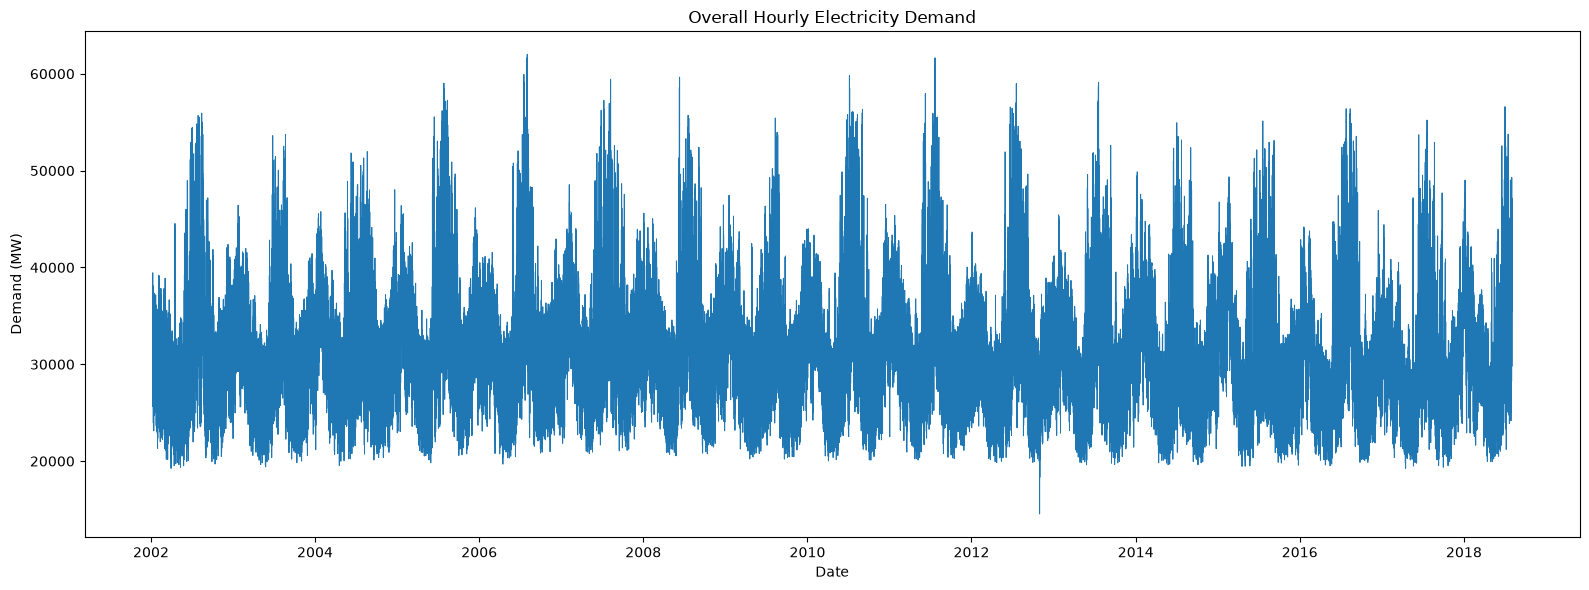

In [8]:
plt.figure(figsize=(16, 6))
plt.plot(
    df.index,
    df["PJME_MW"],
    linewidth=0.7
)
plt.title("Overall Hourly Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.tight_layout()
plt.show()

In [9]:
hourly_demand = (df.groupby("Hour")["PJME_MW"].mean())
hourly_demand

Hour
0     29523.789126
1     27534.414312
2     26339.189473
3     25674.638242
4     25412.983309
5     25747.376632
6     27160.779706
7     29608.787969
8     31488.667493
9     32627.402743
10    33496.486696
11    34197.449017
12    34589.229714
13    34760.901008
14    34918.655759
15    34943.309701
16    35068.189886
17    35597.819699
18    36421.016196
19    36425.255495
20    36105.706330
21    35740.395307
22    34452.719385
23    32046.868121
Name: PJME_MW, dtype: float64

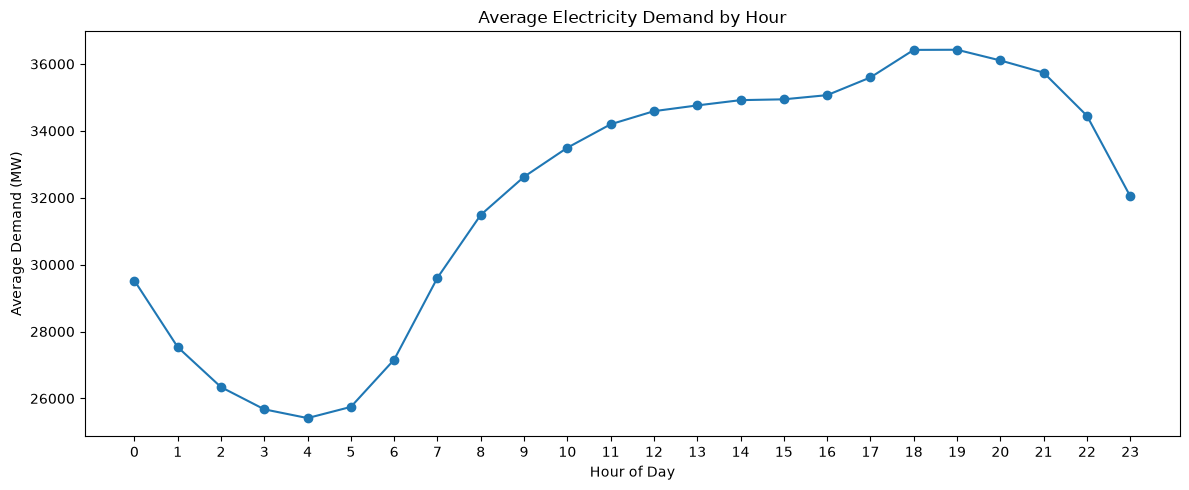

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(
    hourly_demand.index,
    hourly_demand.values,
    marker="o"
)
plt.title("Average Electricity Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

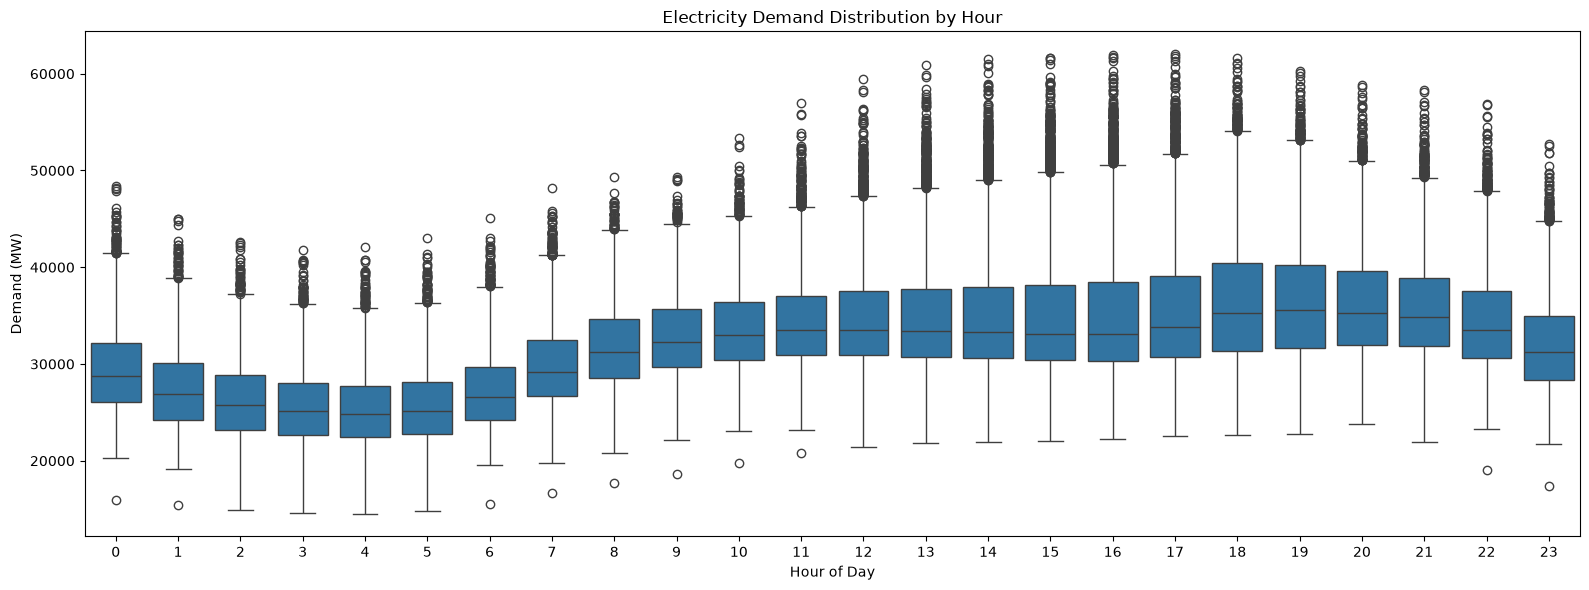

In [11]:
plt.figure(figsize=(16, 6))
sns.boxplot(
    data=df,
    x="Hour",
    y="PJME_MW"
)
plt.title("Electricity Demand Distribution by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Demand (MW)")
plt.tight_layout()
plt.show()

In [12]:
df["Date"] = df.index.date

In [13]:
daily_demand = (df.groupby("Date")["PJME_MW"].mean())

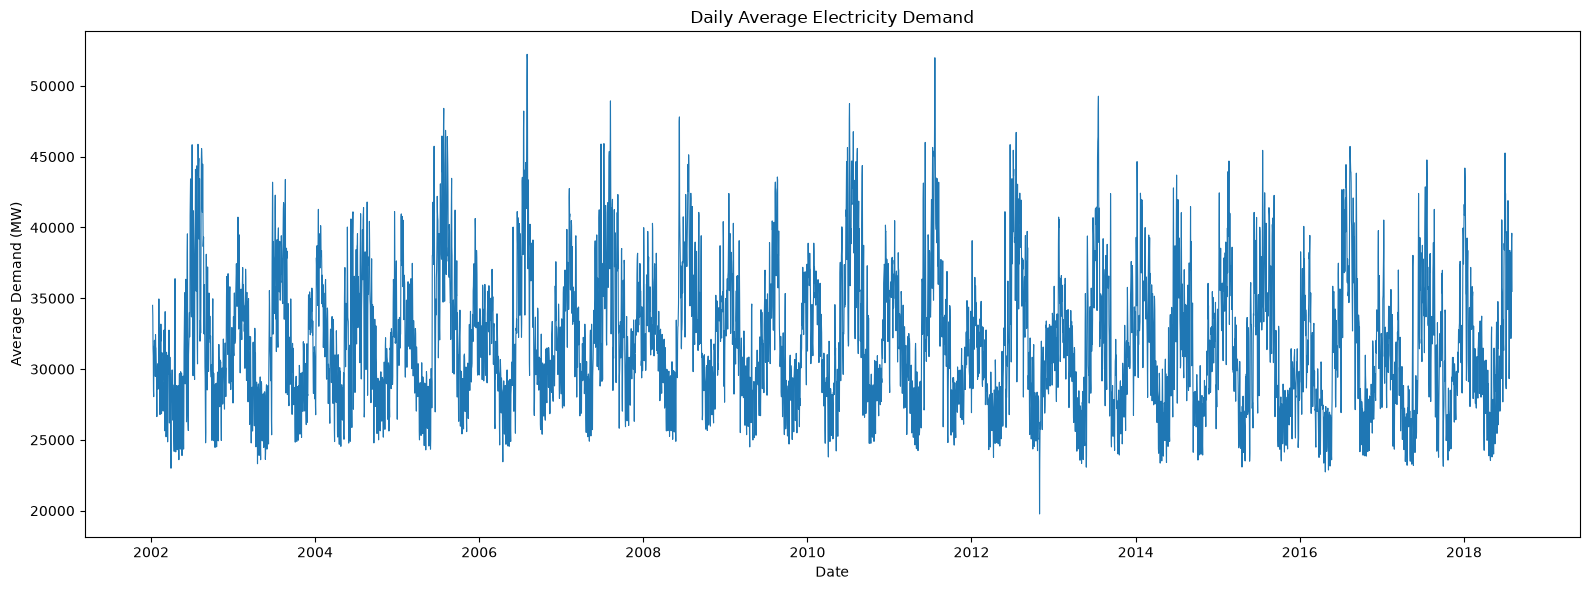

In [14]:
plt.figure(figsize=(16, 6))
plt.plot(
    daily_demand.index,
    daily_demand.values,
    linewidth=0.8
)
plt.title("Daily Average Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Average Demand (MW)")
plt.tight_layout()
plt.show()

In [15]:
daily_total = (df["PJME_MW"].resample("D").sum())

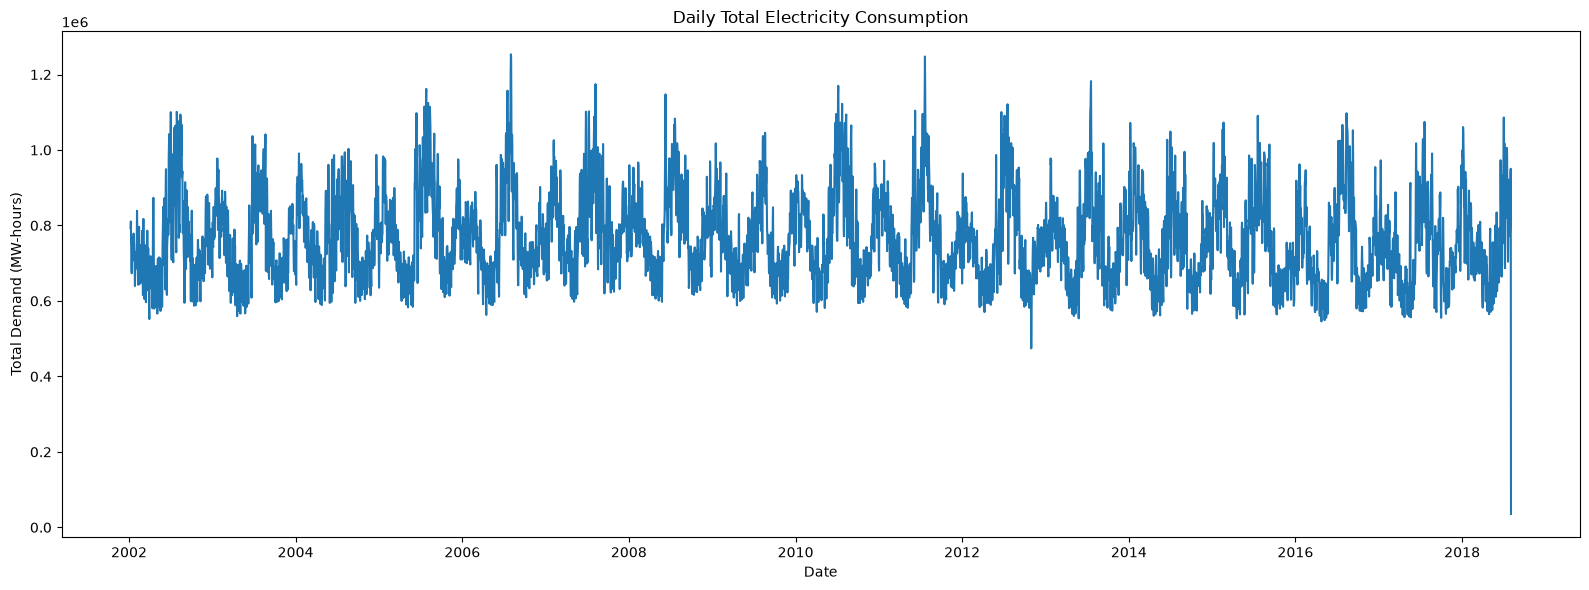

In [16]:
plt.figure(figsize=(16, 6))
plt.plot(
    daily_total.index,
    daily_total.values
)
plt.title("Daily Total Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("Total Demand (MW-hours)")
plt.tight_layout()
plt.show()

In [17]:
weekly_demand = (df.groupby("DayOfWeek")["PJME_MW"].mean())

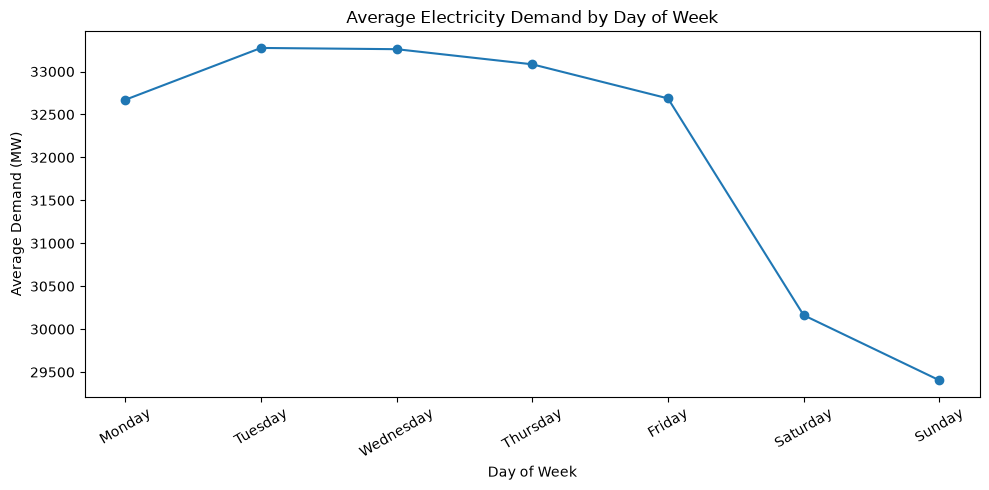

In [18]:
day_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
plt.figure(figsize=(10, 5))
plt.plot(
    weekly_demand.index,
    weekly_demand.values,
    marker="o"
)
plt.title("Average Electricity Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand (MW)")
plt.xticks(
    range(7),
    day_names,
    rotation=30
)
plt.tight_layout()
plt.show()

In [19]:
weekend_comparison = (df.groupby("IsWeekend")["PJME_MW"].mean())
print(weekend_comparison)

IsWeekend
0    32995.670493
1    29783.694215
Name: PJME_MW, dtype: float64


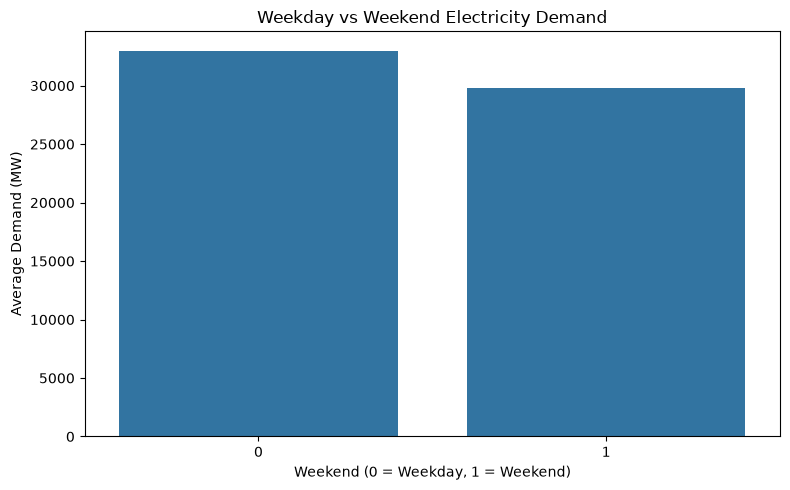

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(x=weekend_comparison.index,y=weekend_comparison.values)
plt.title("Weekday vs Weekend Electricity Demand")
plt.xlabel("Weekend (0 = Weekday, 1 = Weekend)")
plt.ylabel("Average Demand (MW)")
plt.tight_layout()
plt.show()

In [21]:
monthly_demand = (df.groupby("Month")["PJME_MW"].mean())

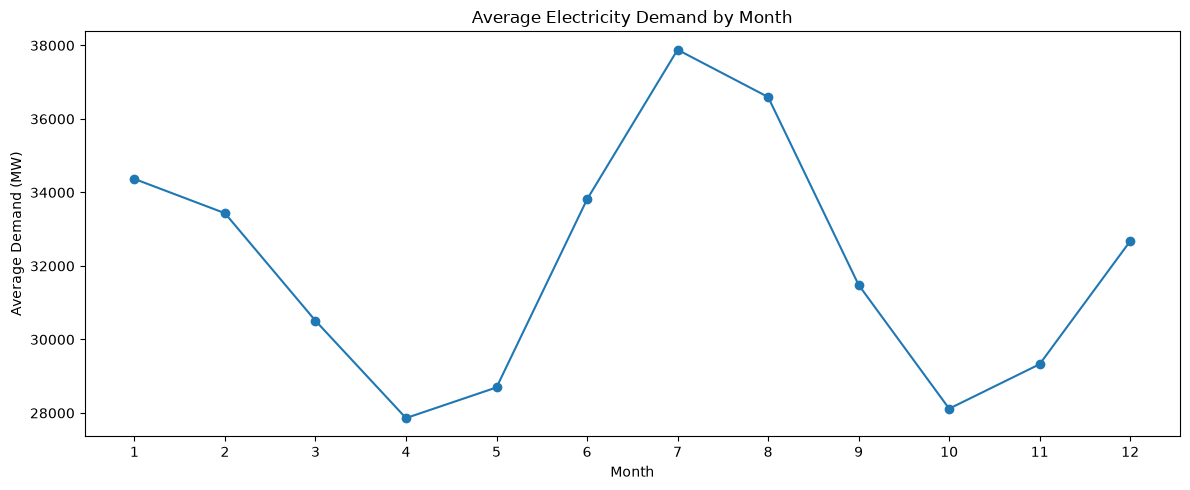

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    marker="o"
)
plt.title("Average Electricity Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [23]:
yearly_demand = (df.groupby("Year")["PJME_MW"].mean())
print(yearly_demand)

Year
2002    31545.007275
2003    31696.652226
2004    32268.228541
2005    33308.357477
2006    32407.062842
2007    33611.355137
2008    32927.883140
2009    31849.275628
2010    33099.388014
2011    32366.498288
2012    31438.515084
2013    31704.597432
2014    31496.549943
2015    31710.209418
2016    31337.811532
2017    30651.965696
2018    31781.655830
Name: PJME_MW, dtype: float64


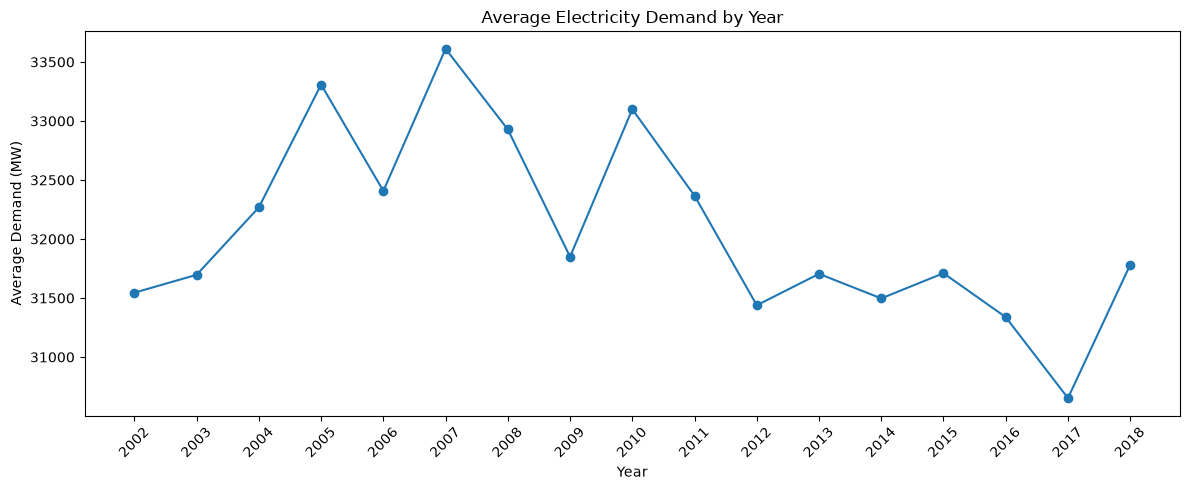

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(
    yearly_demand.index,
    yearly_demand.values,
    marker="o"
)
plt.title("Average Electricity Demand by Year")
plt.xlabel("Year")
plt.ylabel("Average Demand (MW)")
plt.xticks(
    yearly_demand.index,
    rotation=45
)
plt.tight_layout()
plt.show()

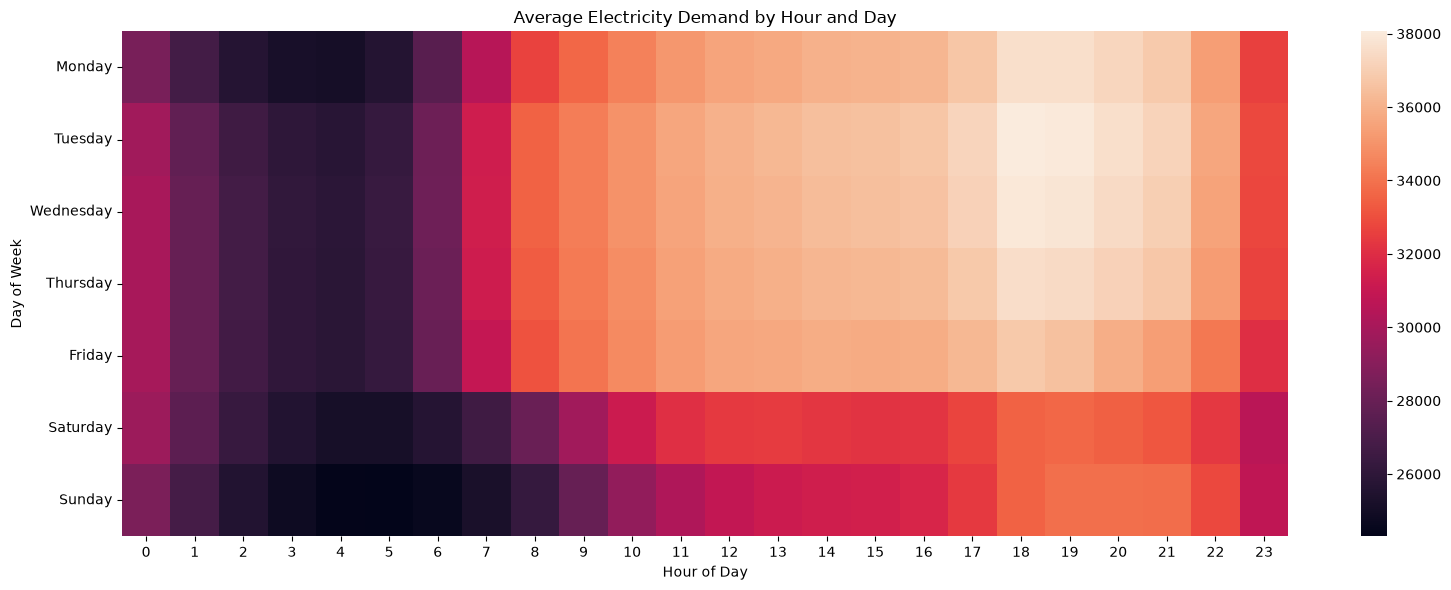

In [26]:
hour_day = df.pivot_table(
    values="PJME_MW",
    index="DayOfWeek",
    columns="Hour",
    aggfunc="mean"
)
plt.figure(figsize=(16, 6))
sns.heatmap(
    hour_day,
    xticklabels=range(24),
    yticklabels=day_names
)
plt.title("Average Electricity Demand by Hour and Day")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

In [27]:
df["PeakPeriod"] = np.where(
    df["Hour"].between(8, 20),
    "Peak",
    "Off-Peak"
)

In [28]:
peak_comparison = (
    df.groupby("PeakPeriod")["PJME_MW"]
    .mean()
)
print(peak_comparison)

PeakPeriod
Off-Peak    29021.994689
Peak        34664.622287
Name: PJME_MW, dtype: float64


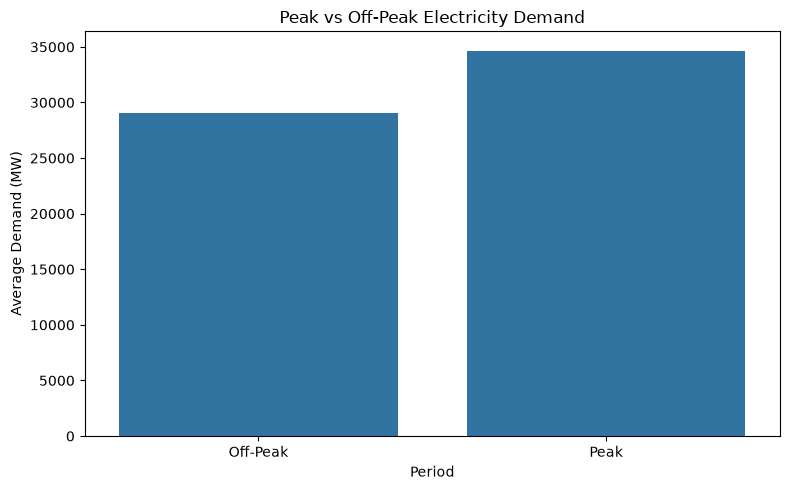

In [29]:
plt.figure(figsize=(8, 5))
sns.barplot(x=peak_comparison.index, y=peak_comparison.values)
plt.title("Peak vs Off-Peak Electricity Demand")
plt.xlabel("Period")
plt.ylabel("Average Demand (MW)")
plt.tight_layout()
plt.show()

In [30]:
peak_hours = (
    df.groupby("Hour")["PJME_MW"]
    .mean()
    .sort_values(ascending=False)
)
print(peak_hours.head(10))

Hour
19    36425.255495
18    36421.016196
20    36105.706330
21    35740.395307
17    35597.819699
16    35068.189886
15    34943.309701
14    34918.655759
13    34760.901008
12    34589.229714
Name: PJME_MW, dtype: float64


In [31]:
low_hours = (
    df.groupby("Hour")["PJME_MW"]
    .mean()
    .sort_values()
)
print(low_hours.head(10))

Hour
4     25412.983309
3     25674.638242
5     25747.376632
2     26339.189473
6     27160.779706
1     27534.414312
0     29523.789126
7     29608.787969
8     31488.667493
23    32046.868121
Name: PJME_MW, dtype: float64


In [32]:
lag_columns = [
    "Lag_1",
    "Lag_24",
    "Lag_48",
    "Lag_168"
]
lag_correlation = df[["PJME_MW"] + lag_columns].corr()
print(lag_correlation["PJME_MW"])

PJME_MW    1.000000
Lag_1      0.974793
Lag_24     0.891475
Lag_48     0.772853
Lag_168    0.782470
Name: PJME_MW, dtype: float64


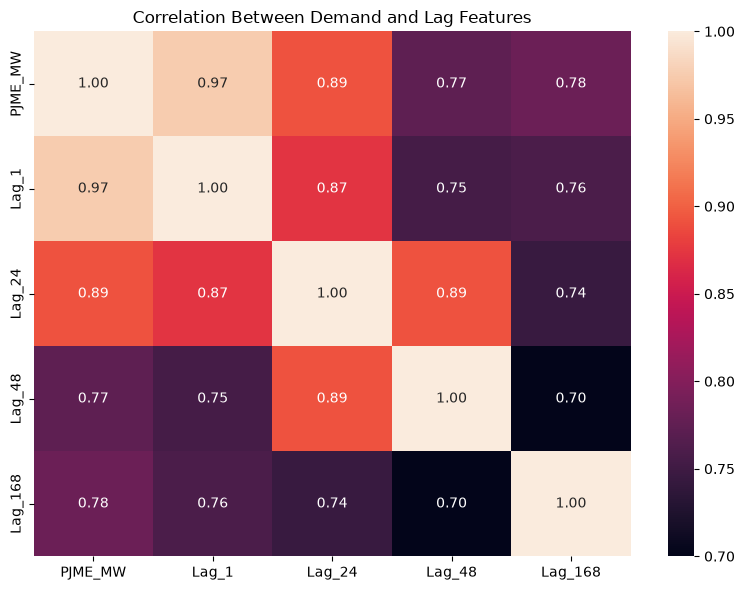

In [33]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    lag_correlation,
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Between Demand and Lag Features")
plt.tight_layout()
plt.show()

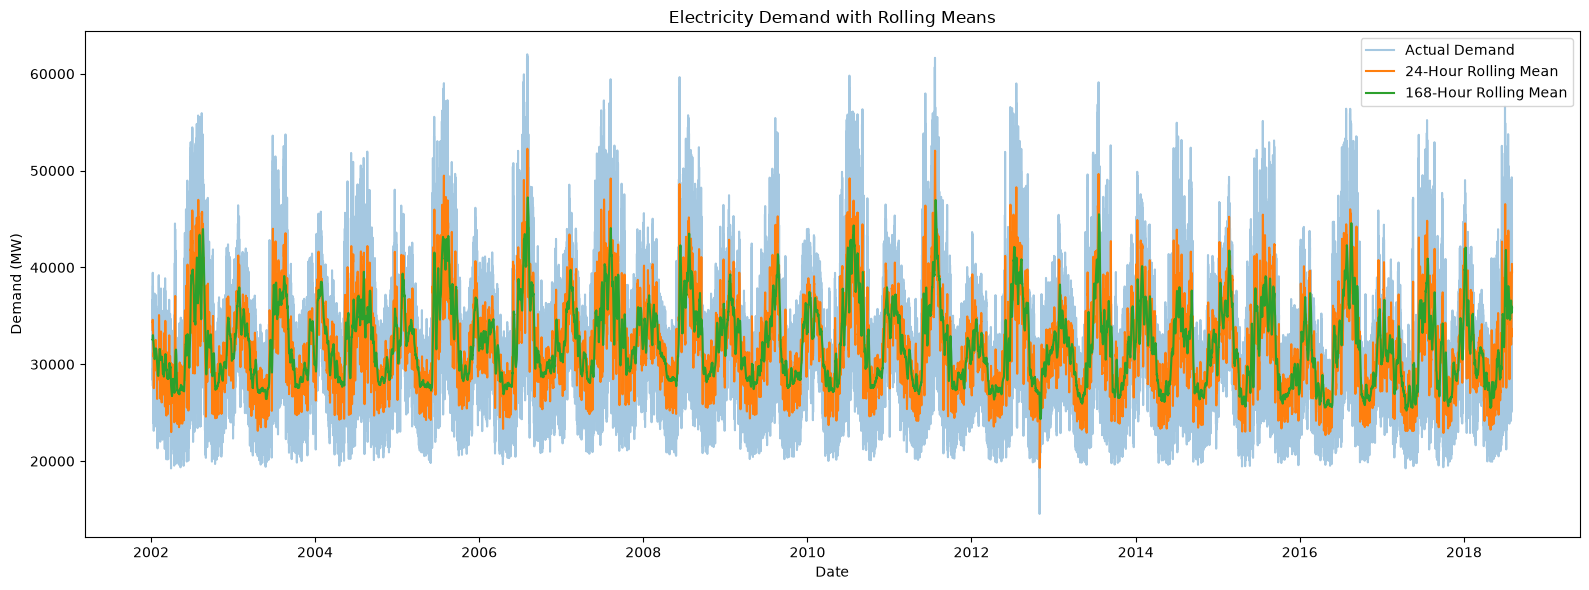

In [34]:
plt.figure(figsize=(16, 6))
plt.plot(
    df.index,
    df["PJME_MW"],
    alpha=0.4,
    label="Actual Demand"
)
plt.plot(
    df.index,
    df["RollingMean_24"],
    label="24-Hour Rolling Mean"
)
plt.plot(
    df.index,
    df["RollingMean_168"],
    label="168-Hour Rolling Mean"
)
plt.title("Electricity Demand with Rolling Means")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.tight_layout()
plt.show()

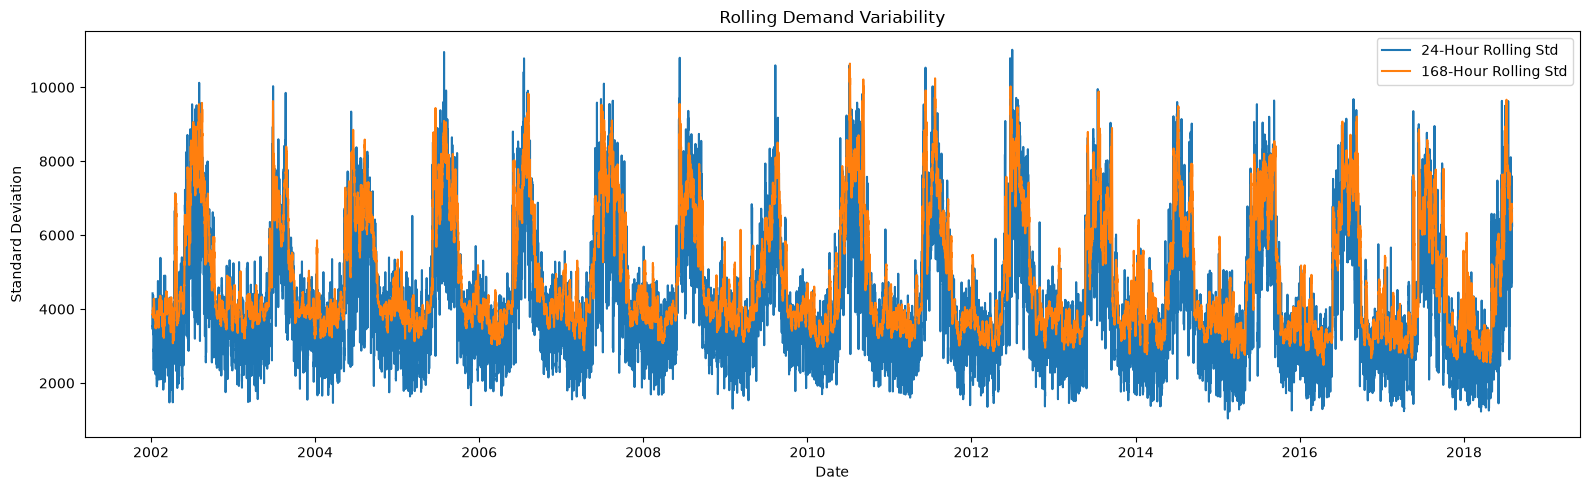

In [35]:
plt.figure(figsize=(16, 5))
plt.plot(
    df.index,
    df["RollingStd_24"],
    label="24-Hour Rolling Std"
)
plt.plot(
    df.index,
    df["RollingStd_168"],
    label="168-Hour Rolling Std"
)
plt.title("Rolling Demand Variability")
plt.xlabel("Date")
plt.ylabel("Standard Deviation")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
demand_sample = df["PJME_MW"].iloc[-24 * 30:]

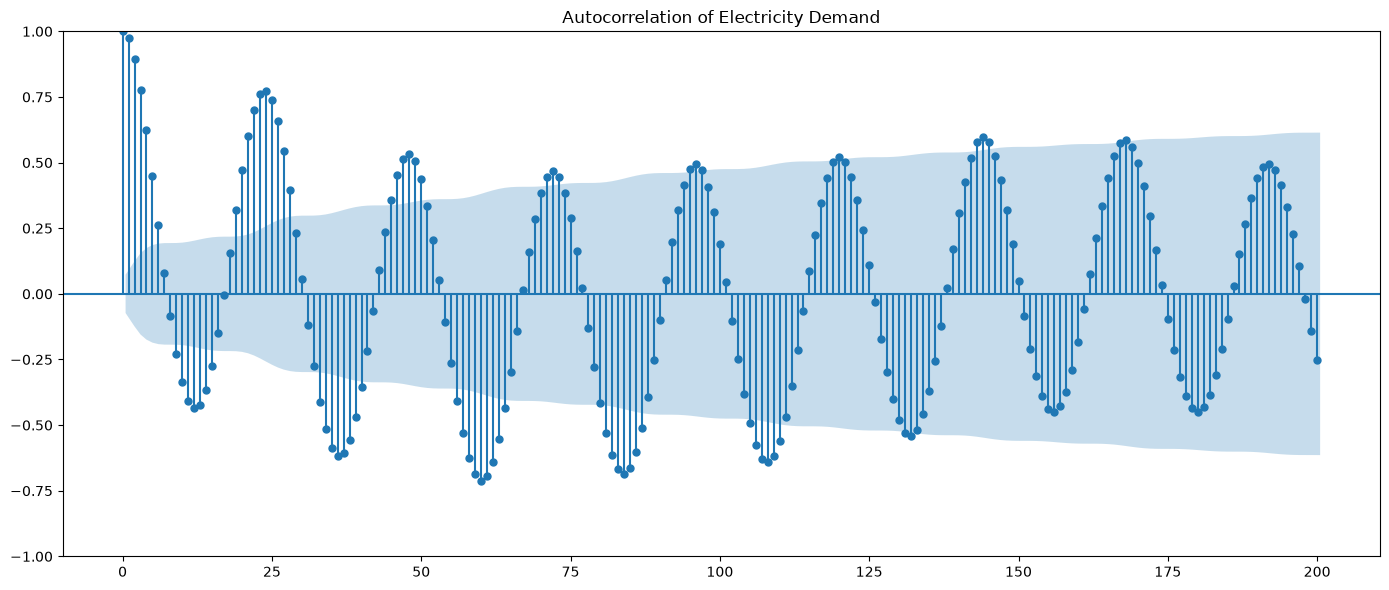

In [37]:
plt.figure(figsize=(14, 6))
plot_acf(
    demand_sample,
    lags=200,
    ax=plt.gca()
)
plt.title("Autocorrelation of Electricity Demand")
plt.tight_layout()
plt.show()

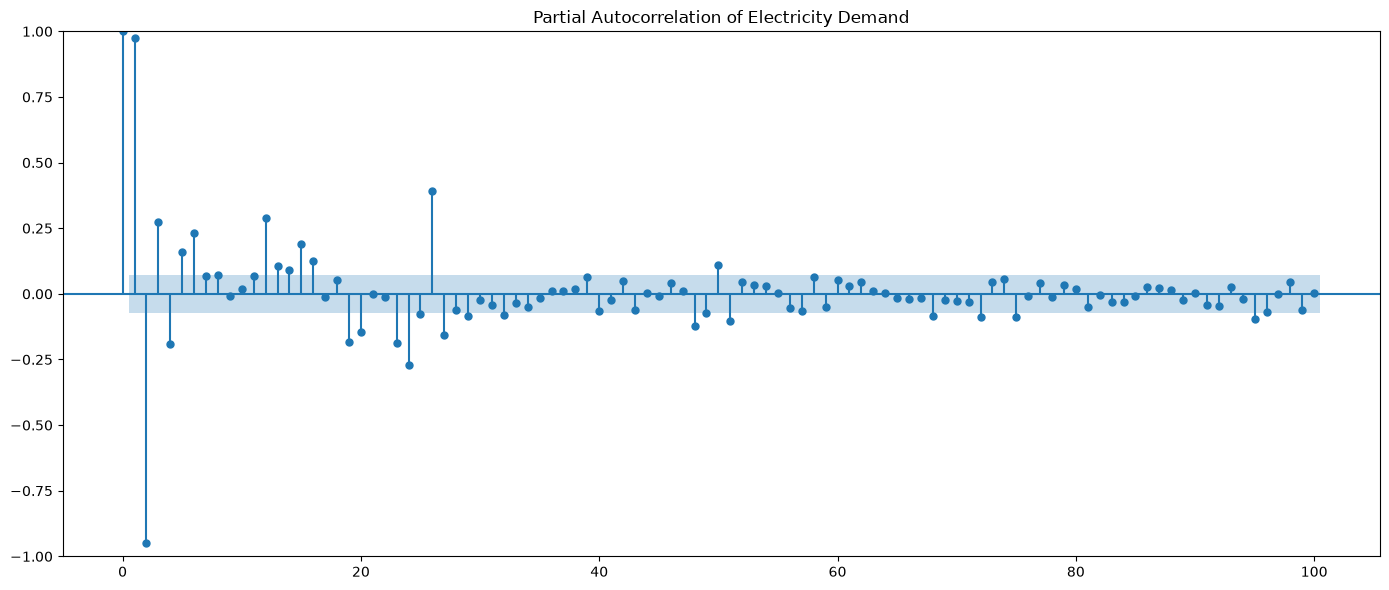

In [38]:
plt.figure(figsize=(14, 6))
plot_pacf(
    demand_sample,
    lags=100,
    method="ywm",
    ax=plt.gca()
)
plt.title("Partial Autocorrelation of Electricity Demand")
plt.tight_layout()
plt.show()

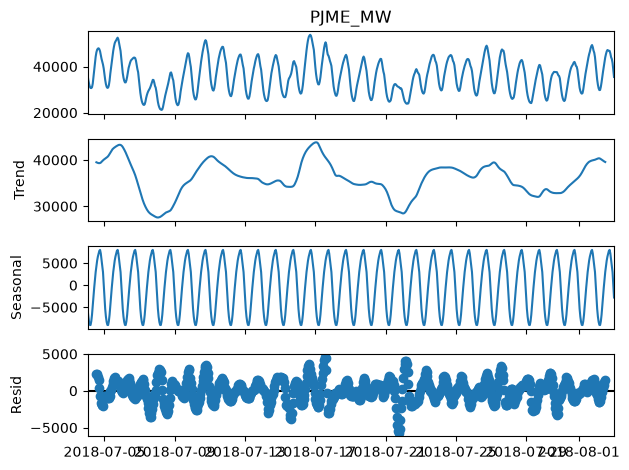

In [40]:
decomposition_daily = seasonal_decompose(
    demand_sample,
    model="additive",
    period=24
)
decomposition_daily.plot()
plt.tight_layout()
plt.show()

In [41]:
weekly_sample = df["PJME_MW"].iloc[-24 * 12 * 7:]

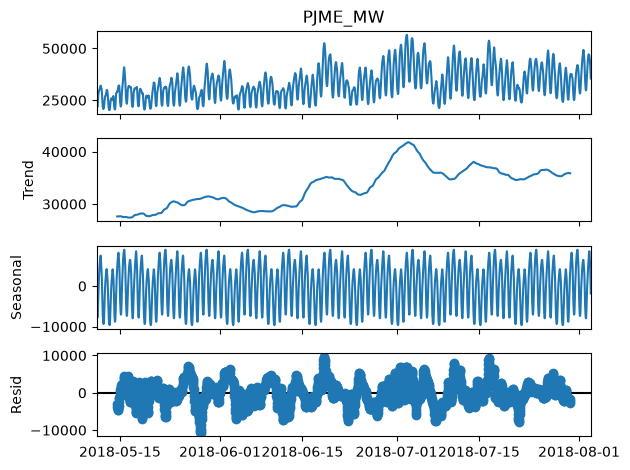

In [43]:
decomposition_weekly = seasonal_decompose(
    weekly_sample,
    model="additive",
    period=168
)
decomposition_weekly.plot()
plt.tight_layout()
plt.show()

In [44]:
print(df.groupby("Season")["PJME_MW"].mean())

Season
Autumn    29626.149711
Spring    29034.884244
Summer    36112.459515
Winter    33507.714119
Name: PJME_MW, dtype: float64


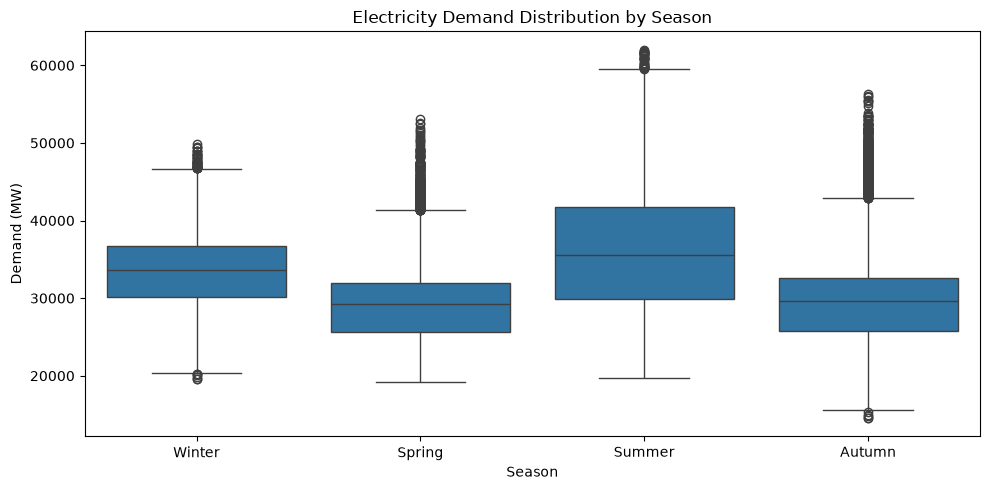

In [45]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="Season",
    y="PJME_MW"
)
plt.title("Electricity Demand Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Demand (MW)")
plt.tight_layout()
plt.show()

In [46]:
monthly_yearly = (
    df.groupby(
        ["Year", "Month"]
    )["PJME_MW"]
    .mean()
    .reset_index()
)

In [47]:
year_month = monthly_yearly.pivot(
    index="Year",
    columns="Month",
    values="PJME_MW"
)

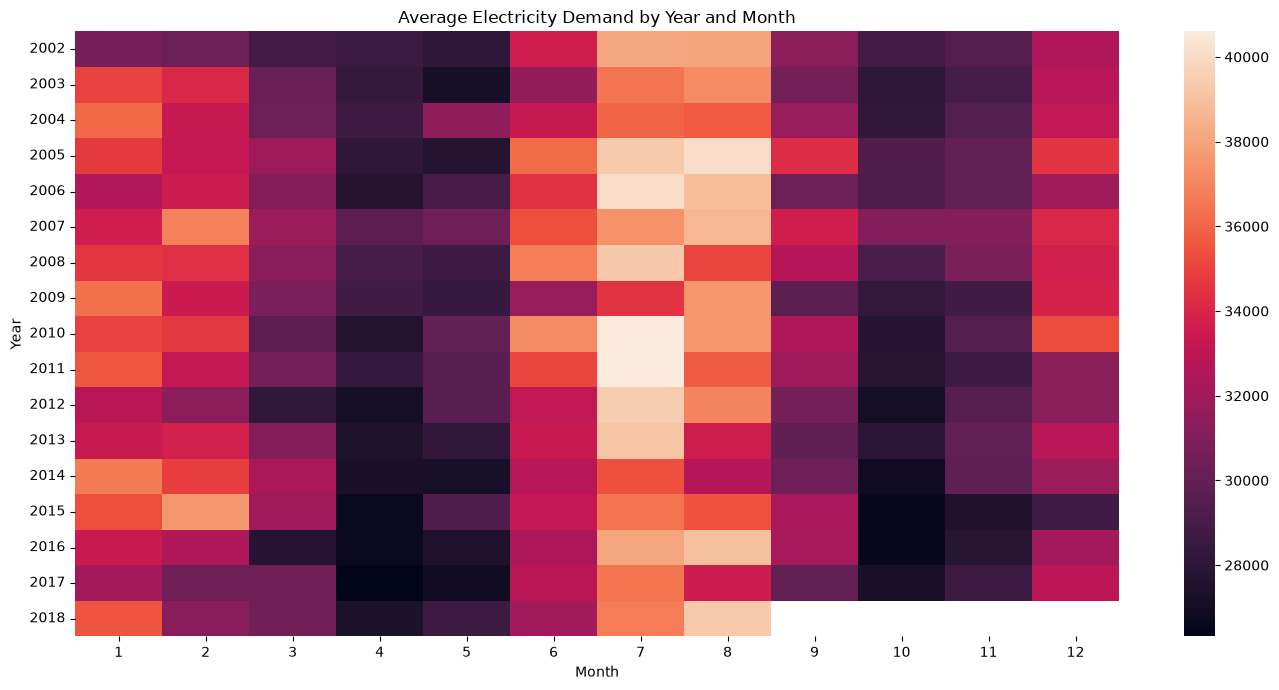

In [48]:
plt.figure(figsize=(14, 7))
sns.heatmap(
    year_month,
    annot=False
)
plt.title("Average Electricity Demand by Year and Month")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

In [49]:
top_demand = df.nlargest(
    20,
    "PJME_MW"
)[
    ["PJME_MW"]
]
top_demand

,PJME_MW
Datetime,
2006-08-02 17:00:00,62009.0
2006-08-02 16:00:00,61909.0
2006-08-03 17:00:00,61796.0
2006-08-03 16:00:00,61770.0
2011-07-22 15:00:00,61646.0
2006-08-01 17:00:00,61643.0
2006-08-02 15:00:00,61641.0
2006-08-02 18:00:00,61610.0
2011-07-22 16:00:00,61608.0


In [50]:
top_demand = df.nlargest(
    20,
    "PJME_MW"
).copy()

top_demand[
    [
        "PJME_MW",
        "Hour",
        "DayOfWeek",
        "Month",
        "Year",
        "IsWeekend"
    ]
]

,PJME_MW,Hour,DayOfWeek,Month,Year,IsWeekend
Datetime,,,,,,
2006-08-02 17:00:00,62009.0,17,2,8,2006,0
2006-08-02 16:00:00,61909.0,16,2,8,2006,0
2006-08-03 17:00:00,61796.0,17,3,8,2006,0
2006-08-03 16:00:00,61770.0,16,3,8,2006,0
2011-07-22 15:00:00,61646.0,15,4,7,2011,0
2006-08-01 17:00:00,61643.0,17,1,8,2006,0
2006-08-02 15:00:00,61641.0,15,2,8,2006,0
2006-08-02 18:00:00,61610.0,18,2,8,2006,0
2011-07-22 16:00:00,61608.0,16,4,7,2011,0
